# Simple CoNGA pipeline

This should be roughly equivalent to running the two commands:

**SETUP:**
```
python scripts/setup_10x_for_conga.py --filtered_contig_annotations_csvfile ./conga_example_datasets_v1/vdj_v1_hs_pbmc3_t_filtered_contig_annotations.csv --organism human --output_clones_file tmp_hs_pbmc_clones.tsv
```

**ANALYSIS:**
```
python scripts/run_conga.py --graph_vs_graph --graph_vs_features --find_hotspot_features --tcr_clumping --match_to_tcr_database --gex_data ./conga_example_datasets_v1/vdj_v1_hs_pbmc3_5gex_filtered_gene_bc_matrices_h5.h5 --gex_data_type 10x_h5 --clones_file tmp_hs_pbmc_clones.tsv --organism human --outfile_prefix tmp_hs_pbmc 
```

In [1]:
%matplotlib inline
import sys
from os.path import exists

# this is the repository I pulled/downloaded from github: 
CONGA_PATH = '/home/pbradley/gitrepos/conga/'
# confirm that it's the right level directory (since the repo and library have the same name)
assert exists(CONGA_PATH+'/README.md')
sys.path.append(CONGA_PATH)

import scanpy as sc
import conga
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



## Input data, output paths

In [2]:
# You might have to change these paths depending on what you want to analyze
#
# Here I'm using datasets from a collection on dropbox, downloaded with this command: 
# wget https://www.dropbox.com/s/r7rpsftbtxl89y5/conga_example_datasets_v1.zip
#
gex_datafile = './conga_example_datasets_v1/vdj_v1_hs_pbmc3_5gex_filtered_gene_bc_matrices_h5.h5'
gex_datatype = '10x_h5' # other possibilities right now: ['10x_mtx', 'h5ad'] (h5ad from scanpy)
tcr_datafile = './conga_example_datasets_v1/vdj_v1_hs_pbmc3_t_filtered_contig_annotations.csv'
organism = 'human'

clones_file = 'tmp_hs_pbmc_clones.tsv'
outfile_prefix = 'tmp_hs_pbmc' # this string will be prepended to results (figure and table) filenames

assert exists(gex_datafile)
assert exists(tcr_datafile)

## Setup for conga: make a TCRdist clones_file

In [3]:
# this creates the TCRdist 'clones file'
conga.tcrdist.make_10x_clones_file.make_10x_clones_file( tcr_datafile, organism, clones_file )

# Note: we no longer precompute a KernelPCA kernel-PCs file here. CoNGA automatically
# selects the best available TCR representation when the data is loaded below --
# the fast vectorized TCRdist encoding for organisms in
# conga.tcrdist.vectorized.SUPPORTED_ORGANISMS (18 organisms as of this writing,
# including 'human'), falling back to KernelPCA or exact TCRdist neighbors otherwise.

ab_counts: [((1, 1), 2909), ((2, 1), 281), ((1, 2), 101), ((2, 2), 65)]
old_unpaired_barcodes: 569 old_paired_barcodes: 3356 new_stringent_paired_barcodes: 3190
compute tcrdist distance matrix for 3000 clonotypes
Using C++ TCRdist calculator
util.run_command: cmd= /home/pbradley/gitrepos/conga/tcrdist_cpp/bin/find_neighbors -f tmp_hs_pbmc_clones_AB.dist_50_kpcs_tcrs.tsv --only_tcrdists -d /home/pbradley/gitrepos/conga/tcrdist_cpp/db/tcrdist_info_human.txt -o tmp_hs_pbmc_clones_AB.dist_50_kpcs
running KernelPCA with None kernel distance matrix shape= (3000, 3000) D.max()= 502.0 force_Dmax= None
writing TCRdist kernel PCs to outfile: tmp_hs_pbmc_clones_AB.dist_50_kpcs


## Read the data, create a `scanpy` `AnnData` object with everything inside

In [4]:
adata = conga.preprocess.read_dataset(
    gex_datafile, gex_datatype, clones_file, allow_missing_kpca_file=True,
)

# store the organism info in adata
adata.uns['organism'] = organism

adata

reading: ./conga_example_datasets_v1/vdj_v1_hs_pbmc3_5gex_filtered_gene_bc_matrices_h5.h5 of type 10x_h5


Variable names are not unique. To make them unique, call `.var_names_make_unique`.
Variable names are not unique. To make them unique, call `.var_names_make_unique`.
/home/pbradley/gitrepos/conga/conga/preprocess.py:213: DeprecationWarning: Use is_view instead of isview, isview will be removed in the future.
  if adata.isview: # this is so weird


total barcodes: 7231 (7231, 33538)
reading: tmp_hs_pbmc_clones.tsv
reading: tmp_hs_pbmc_clones_AB.dist_50_kpcs
Reducing to the 3176 barcodes (out of 7231) with paired TCR sequence data


AnnData object with n_obs × n_vars = 3176 × 33538
    obs: 'va', 'ja', 'cdr3a', 'cdr3a_nucseq', 'vb', 'jb', 'cdr3b', 'cdr3b_nucseq'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'conga_results', 'conga_stats', 'organism'
    obsm: 'X_pca_tcr'

Note that the AnnData object contains the TCR sequence information in the `obs` array, stored with the  `['va',..., 'cdr3b_nucseq']` fields.

The TCR neighbor representation (vectorized encoding, KernelPCA, or exact TCRdist, depending on organism and dataset size) is selected and built automatically during the clustering/dimensionality-reduction step below, not at this point.

In [6]:
# CDR3-alpha regions:
adata.obs['cdr3a'].head(3)

AAACCTGAGATCTGAA-1    CAASIGPLGTGTASKLTF
AAACCTGAGGAACTGC-1          CAASDNTDKLIF
AAACCTGAGGAGTCTG-1      CAVEANNAGNNRKLIW
Name: cdr3a, dtype: object

## Do some very basic scGEX filtering

You could customize this or replace it with something else entirely.

After running this (or your replacement), the following should be true:
* `adata.X` is a dense matrix just containing the highly variable genes, normalized, `log1p`ed, scaled, and ready for running PCA.
* The T cell receptor V and J genes have been eliminated from `adata.X`, so they don't influence the GEX clusters/neighbor graphs. (Or the IG receptor genes, if analyzing BCR data).
* 'Antibody' features (ADT/surface protein/pMHC) have been eliminated from `adata.X`. See the `run_conga.py` argument `--include_protein_features` for an approach to including these additional features into the GEX graphs. They can still be present in `adata.raw.X`; if so they will be included in DEG analyses. 
* `adata.raw.X` has been normalized (all rows sum to 10,000) and `log1p`'ed
* Cells with too few or too many genes, or high mitochondrial expression, have been eliminated.

It wouldn't be a bad idea to explicitly look for and remove doublet cells, too. That is not done automatically inside this function.

In [7]:
adata = conga.preprocess.filter_and_scale( 
    adata, 
    min_genes_per_cell=200,
    max_genes_per_cell=2500,
    max_percent_mito=0.1,
)

filtered out 80 cells with more than 2500 genes
filtered out 26 cells with more than 0.1 percent mito
get_feature_types_varname: feature_types feature_type_counts: [('Gene Expression', 14939)]
num antibody features: 0


... storing 'va' as categorical
... storing 'ja' as categorical
... storing 'cdr3a' as categorical
... storing 'cdr3a_nucseq' as categorical
... storing 'vb' as categorical
... storing 'jb' as categorical


excluding 94 TR genes (89 variable)
excluding 1 sexlinked genes
total of 1022 variable genes (3070, 14939)
Normalize and logging matrix...
get_feature_types_varname: feature_types feature_type_counts: [('Gene Expression', 1022)]
feature_types counter: [('Gene Expression', 14939)]
normalize_and_log_the_raw_matrix: adata.raw.X.max()=  588.0


... storing 'cdr3b' as categorical
... storing 'cdr3b_nucseq' as categorical
... storing 'feature_types' as categorical
... storing 'genome' as categorical


## Now we reduce to a single cell per TCR clonotype

Do this by computing GEX distances and picking the most representative cell for each clonotype (the one with the smallest average distance to all other cells in the clonotype)

In [8]:
adata = conga.preprocess.reduce_to_single_cell_per_clone(adata)

adata

compute pca to find rep cell for each clone (3070, 1022)
num_clones: 2896
normalize_and_log_the_raw_matrix:: matrix is already logged
choose representative cell for clone: 0 2896 (3070, 1022)
choose representative cell for clone: 1000 2896 (3070, 1022)
choose representative cell for clone: 2000 2896 (3070, 1022)
reduce from 3070 cells to 2896 cells (one per clonotype)


AnnData object with n_obs × n_vars = 2896 × 1022
    obs: 'va', 'ja', 'cdr3a', 'cdr3a_nucseq', 'vb', 'jb', 'cdr3b', 'cdr3b_nucseq', 'n_genes', 'percent_mito', 'n_counts', 'clone_sizes', 'gex_variation'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'conga_results', 'conga_stats', 'organism', 'log1p', 'hvg', 'raw_matrix_is_logged', 'pca'
    obsm: 'X_pca_tcr'
    varm: 'PCs'
    layers: 'scaled'

## Now that we've reduced to a single cell per clonotype, run clustering and dimensionality reduction for GEX and for TCR

In [9]:
adata = conga.preprocess.cluster_and_tsne_and_umap( adata )


computing X_pca_gex using sc.tl.pca
ran louvain clustering: louvain_gex
ran louvain clustering: louvain_tcr


### These features are stored in `adata.obs` and in `adata.obsm`

* `adata.obs['clusters_gex']` -- GEX clusters
* `adata.obs['clusters_tcr']` -- TCR clusters
* `adata.obsm['X_gex_2d']` -- GEX 2D landscape coordinates (from UMAP)
* `adata.obsm['X_tcr_2d']` -- TCR 2D landscape coordinates (from UMAP)
* `adata.obsm['X_pca_gex']` -- GEX principal components
* `adata.obsm['X_pca_tcr']` -- TCRdist kernel principal components (only present if KernelPCA was the selected representation; use `conga.preprocess.get_active_tcr_representation(adata)` to check which representation was actually used)


In [10]:
adata

AnnData object with n_obs × n_vars = 2896 × 1022
    obs: 'va', 'ja', 'cdr3a', 'cdr3a_nucseq', 'vb', 'jb', 'cdr3b', 'cdr3b_nucseq', 'n_genes', 'percent_mito', 'n_counts', 'clone_sizes', 'gex_variation', 'louvain_gex', 'clusters_gex', 'louvain_tcr', 'clusters_tcr'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'conga_results', 'conga_stats', 'organism', 'log1p', 'hvg', 'raw_matrix_is_logged', 'pca', 'neighbors', 'umap', 'louvain'
    obsm: 'X_pca_tcr', 'X_pca_gex', 'X_umap_gex', 'X_gex_2d', 'X_umap_tcr', 'X_tcr_2d'
    varm: 'PCs'
    layers: 'scaled'
    obsp: 'distances', 'connectivities'

### Make UMAP landscape plots colored by cluster assignments

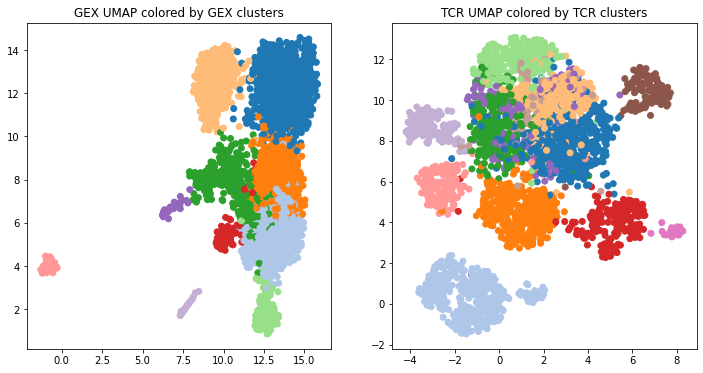

In [11]:
plt.figure(figsize=(12,6))
plt.subplot(121)
xy = adata.obsm['X_gex_2d']
clusters = np.array(adata.obs['clusters_gex'])
cmap = plt.get_cmap('tab20')
colors = [ cmap.colors[x%20] for x in clusters]
plt.scatter( xy[:,0], xy[:,1], c=colors)
plt.title('GEX UMAP colored by GEX clusters')

plt.subplot(122)
xy = adata.obsm['X_tcr_2d']
clusters = np.array(adata.obs['clusters_tcr'])
cmap = plt.get_cmap('tab20')
colors = [ cmap.colors[x%20] for x in clusters]
plt.scatter( xy[:,0], xy[:,1], c=colors)
plt.title('TCR UMAP colored by TCR clusters');



## Compute the GEX and TCR neighbor sets

The neighbors are stored as GEX,TCR tuples in the `all_nbrs` dictionary indexed by `nbr_frac` (neighbor fraction: nbr_frac = 0.1 means K-nearest neighbor graph with `K = 0.1*num_clonotypes`)

So, to unpack the GEX and TCR neighbor sets for a given value of `nbr_frac`, do: 
```
nbrs_gex, nbrs_tcr = all_nbrs[nbr_frac]
```

We also do a bit of other miscellaneous setup here...

In [12]:
# these are the nbrhood sizes, as a fraction of the entire dataset:
nbr_fracs = [0.01, 0.1]

# we use this nbrhood size for computing the nndists
nbr_frac_for_nndists = 0.01

all_nbrs, nndists_gex, nndists_tcr = conga.preprocess.calc_nbrs(
    adata, nbr_fracs, also_calc_nndists=True, nbr_frac_for_nndists=nbr_frac_for_nndists)

# stash these in obs array, they are used in a few places...
adata.obs['nndists_gex'] = nndists_gex
adata.obs['nndists_tcr'] = nndists_tcr

conga.preprocess.setup_tcr_cluster_names(adata) #stores in adata.uns

compute D gex 2896
argpartitions: 0.01 2896 gex
calculate nndists: gex 0.01
DONE calculating nndists: gex 0.01
argpartitions: 0.1 2896 gex
compute D tcr 2896
argpartitions: 0.01 2896 tcr
calculate nndists: tcr 0.01
DONE calculating nndists: tcr 0.01
argpartitions: 0.1 2896 tcr
setup_tcr_cluster_names: ['0', '1_AV14++', '2_av8', '3', '4_bv6', '5_AV12', '6_BV20', '7_av26', '8', '9_AV9', '10_AV1', '11', '12_AV1']


## Run graph-vs-graph analysis

This will also save the results (a pandas `DataFrame`) to a tsv file `<outfile_prefix>_graph_vs_graph.tsv` and store them in the `adata.uns['conga_results']` dictionary.

In [13]:
results = conga.correlations.run_graph_vs_graph(
    adata, all_nbrs, outfile_prefix=outfile_prefix)

results.head()

find_neighbor_neighbor_interactions:
find_neighbor_cluster_interactions:
find_neighbor_cluster_interactions:
find_neighbor_neighbor_interactions:
find_neighbor_cluster_interactions:
find_neighbor_cluster_interactions:
saved graph_vs_graph results to tsvfile: tmp_hs_pbmc_graph_vs_graph.tsv


,conga_score,num_neighbors_gex,num_neighbors_tcr,overlap,overlap_corrected,mait_fraction,clone_index,nbr_frac,graph_overlap_type,cluster_size,gex_cluster,tcr_cluster,va,ja,cdr3a,vb,jb,cdr3b
407,1.066112e-48,NaN,289.0,94,64,0.914894,107,0.1,gex_cluster_vs_tcr_nbr,115.0,5,10,TRAV1-2*01,TRAJ33*01,CAVMDSNYQLIW,TRBV6-4*01,TRBJ2-5*01,CASSEKTGGQETQYF
391,3.961754e-48,NaN,289.0,98,64,0.908163,89,0.1,gex_cluster_vs_tcr_nbr,121.0,5,10,TRAV1-2*01,TRAJ33*01,CAVKESNYQLIW,TRBV6-2*01,TRBJ2-5*01,CASSYTEQGSETQYF
408,1.287582e-47,NaN,289.0,90,64,0.911111,108,0.1,gex_cluster_vs_tcr_nbr,112.0,5,10,TRAV1-2*01,TRAJ33*01,CAVMDSNYQLIW,TRBV15*01,TRBJ2-3*01,CATSSPPGQGADTQYF
365,3.239912e-47,NaN,289.0,98,63,0.918367,63,0.1,gex_cluster_vs_tcr_nbr,121.0,5,10,TRAV1-2*01,TRAJ33*01,CAAMDSNYQLIW,TRBV6-2*01,TRBJ2-7*01,CASSLKGGGSDEQYF
397,4.358529e-47,NaN,289.0,97,63,0.927835,95,0.1,gex_cluster_vs_tcr_nbr,120.0,5,10,TRAV1-2*01,TRAJ33*01,CAVLDSNYQLIW,TRBV6-5*01,TRBJ2-5*01,CASSTSSGGAETQYF


### conga results are stored in `adata.uns['conga_results']`

This is a dictionary whose keys are strings that can be found in `conga/tags.py` 

Each result should have a corresponding help message (under the key with a `'_help'` suffix) 

In [14]:
adata.uns['conga_results'].keys()

dict_keys(['graph_vs_graph', 'graph_vs_graph_help'])

In [15]:
# another way of getting the graph-vs-graph results DataFrame:
# conga.tags.GRAPH_VS_GRAPH = 'graph_vs_graph'
results = adata.uns['conga_results'][conga.tags.GRAPH_VS_GRAPH]
results.head() 

,conga_score,num_neighbors_gex,num_neighbors_tcr,overlap,overlap_corrected,mait_fraction,clone_index,nbr_frac,graph_overlap_type,cluster_size,gex_cluster,tcr_cluster,va,ja,cdr3a,vb,jb,cdr3b
407,1.066112e-48,NaN,289.0,94,64,0.914894,107,0.1,gex_cluster_vs_tcr_nbr,115.0,5,10,TRAV1-2*01,TRAJ33*01,CAVMDSNYQLIW,TRBV6-4*01,TRBJ2-5*01,CASSEKTGGQETQYF
391,3.961754e-48,NaN,289.0,98,64,0.908163,89,0.1,gex_cluster_vs_tcr_nbr,121.0,5,10,TRAV1-2*01,TRAJ33*01,CAVKESNYQLIW,TRBV6-2*01,TRBJ2-5*01,CASSYTEQGSETQYF
408,1.287582e-47,NaN,289.0,90,64,0.911111,108,0.1,gex_cluster_vs_tcr_nbr,112.0,5,10,TRAV1-2*01,TRAJ33*01,CAVMDSNYQLIW,TRBV15*01,TRBJ2-3*01,CATSSPPGQGADTQYF
365,3.239912e-47,NaN,289.0,98,63,0.918367,63,0.1,gex_cluster_vs_tcr_nbr,121.0,5,10,TRAV1-2*01,TRAJ33*01,CAAMDSNYQLIW,TRBV6-2*01,TRBJ2-7*01,CASSLKGGGSDEQYF
397,4.358529e-47,NaN,289.0,97,63,0.927835,95,0.1,gex_cluster_vs_tcr_nbr,120.0,5,10,TRAV1-2*01,TRAJ33*01,CAVLDSNYQLIW,TRBV6-5*01,TRBJ2-5*01,CASSTSSGGAETQYF


In [16]:
print(adata.uns['conga_results']['graph_vs_graph_help'])

Graph vs graph analysis looks for correlation between GEX and TCR space
by finding statistically significant overlap between two similarity graphs,
one defined by GEX similarity and one by TCR sequence similarity.

Overlap is defined one node (clonotype) at a time by looking for overlap
between that node's neighbors in the GEX graph and its neighbors in the
TCR graph. The null model is that the two neighbor sets are chosen
independently at random.

CoNGA looks at two kinds of graphs: K nearest neighbor (KNN) graphs, where
K = neighborhood size is specified as a fraction of the number of
clonotypes (defaults for K are 0.01 and 0.1), and cluster graphs, where
each clonotype is connected to all the other clonotypes in the same
(GEX or TCR) cluster. Overlaps are computed 3 ways (GEX KNN vs TCR KNN,
GEX KNN vs TCR cluster, and GEX cluster vs TCR KNN), for each of the
K values (called nbr_fracs short for neighbor fractions).

Columns (depend slightly on whether hit is KNN v KNN or KNN v clus

### Some potentially useful statistics are stored in `adata.uns['conga_stats']`

In [17]:
adata.uns['conga_stats']

OrderedDict([('num_cells_w_gex', 7231),
             ('num_features_start', 33538),
             ('num_cells_w_tcr', 3176),
             ('min_genes_per_cell', 200),
             ('max_genes_per_cell', 2500),
             ('max_percent_mito', 0.1),
             ('num_filt_max_genes_per_cell', 80),
             ('num_filt_max_percent_mito', 26),
             ('num_antibody_features', 0),
             ('num_TR_genes', 94),
             ('num_TR_genes_in_hvg_set', 89),
             ('num_highly_variable_genes', 1022),
             ('num_cells_after_filtering', 3070),
             ('num_clonotypes', 2896),
             ('max_clonotype_size', 29),
             ('num_singleton_clonotypes', 2808)])

### Make a scatterplot colored by conga score

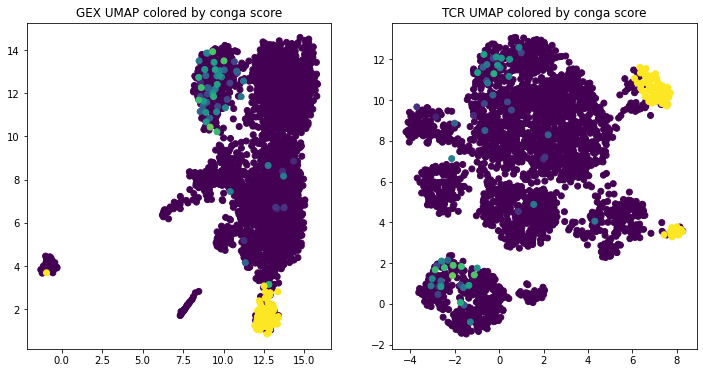

In [18]:
#put the conga hits on top
conga_scores = adata.obs['conga_scores']
colors = np.sqrt(np.maximum(-1*np.log10(conga_scores),0.0))
reorder = np.argsort(colors)

plt.figure(figsize=(12,6))
plt.subplot(121)
xy = adata.obsm['X_gex_2d']
plt.scatter( xy[reorder,0], xy[reorder,1], c=colors[reorder], vmin=0, vmax=np.sqrt(5))
plt.title('GEX UMAP colored by conga score')

plt.subplot(122)
xy = adata.obsm['X_tcr_2d']
plt.scatter( xy[reorder,0], xy[reorder,1], c=colors[reorder], vmin=0, vmax=np.sqrt(5))
plt.title('TCR UMAP colored by conga score');


## Make the CoNGA cluster logos plot

This plot summarizes the CoNGA clusters of size at least 5 (`min_cluster_size`). Some useful options:

* `gex_header_genes`: list of gene names for the thumbnail UMAP plots above the logos. Default is `conga.plotting.default_gex_header_genes[organism]`
* `gex_header_tcr_score_names`: list of tcr scores to show in the thumbnail UMAP plots. Default is `['imhc', 'cdr3len', 'cd8', 'nndists_tcr']`
* `logo_genes`: python list of gene names for the 'GEX logo' shown on the right. Should have length = `logo_gene_width*3 - 2`. Default is `conga.plotting.default_logo_genes[organism]`
* `logo_gene_width`: width of the 'GEX logo' (default is 6).

Note: These arguments also work for the `conga.plotting.make_tcr_clumping_plots` function below.

making tcr score table, #features= 35


... storing 'test' as categorical


run rank_genes_groups [('none', 2768), ('clp_5_10', 73), ('clp_3_1', 23), ('clp_5_12', 20), ('clp_3_5', 12)]
making cluster logos: 0 4 tmp_hs_pbmc_graph_vs_graph_logos.png
making cluster logos: 1 4 tmp_hs_pbmc_graph_vs_graph_logos.png
making cluster logos: 2 4 tmp_hs_pbmc_graph_vs_graph_logos.png
making cluster logos: 3 4 tmp_hs_pbmc_graph_vs_graph_logos.png
making: tmp_hs_pbmc_graph_vs_graph_logos.png
writing help message to file: tmp_hs_pbmc_graph_vs_graph_logos.png_README.txt


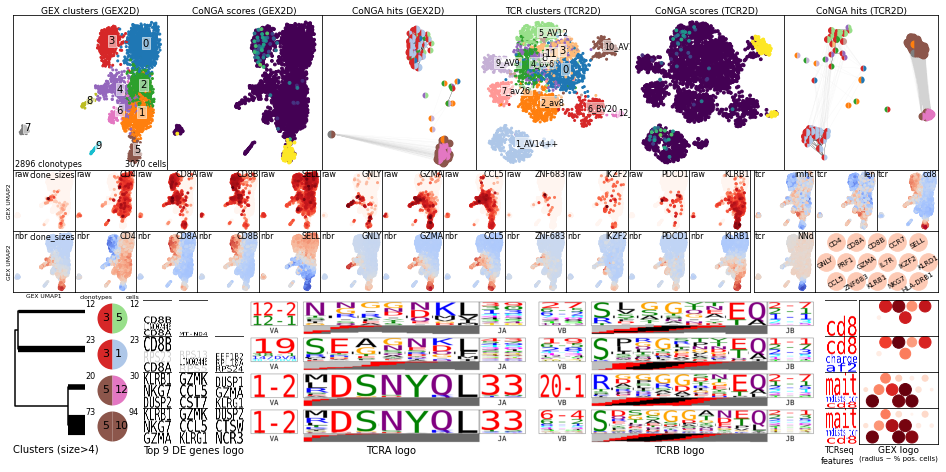

In [19]:
nbrs_gex, nbrs_tcr = all_nbrs[0.1]

min_cluster_size = 5

conga.plotting.make_graph_vs_graph_logos(
    adata,
    outfile_prefix,
    min_cluster_size,
    nbrs_gex,
    nbrs_tcr,
)

# or equivalently:
#
# conga.plotting.make_graph_vs_graph_logos(
#     adata,
#     outfile_prefix,
#     min_cluster_size,
#     nbrs_gex,
#     nbrs_tcr,
#     gex_header_genes = ['clone_sizes','CD4','CD8A','CD8B','SELL','GNLY','GZMA','CCL5','ZNF683','IKZF2','PDCD1','KLRB1'],
#     gex_header_tcr_score_names = ['imhc', 'cdr3len', 'cd8', 'nndists_tcr'],
#     logo_genes = ['CD4','CD8A','CD8B','CCR7','SELL','GNLY','PRF1','GZMA','IL7R','IKZF2','KLRD1','CCL5','ZNF683','KLRB1','NKG7','HLA-DRB1' ],
#     gene_logo_width = 6,
# )



### The image that was saved to disk is higher resolution than the one above here in the notebook 
If you have the python image library (PIL) installed, the following commands should display it.

The image filenames are stored in `adata.uns['conga_results']`. This comes in handy for the html-summary generating code (see the end of this notebook). 


This figure summarizes the results of a CoNGA analysis that produces
scores (CoNGA) and clusters. At the top are six
2D UMAP projections of clonotypes in the dataset based on GEX similarity
(top left three panels) and TCR similarity (top right three panels),
colored from left to right by GEX cluster assignment;
CoNGA score; joint GEX:TCR cluster assignment for
clonotypes with significant CoNGA scores,
using a bicolored disk whose left half indicates GEX cluster and whose right
half indicates TCR cluster; TCR cluster; CoNGA; GEX:TCR cluster
assignments for CoNGA hits, as in the third panel.

Below are two rows of GEX landscape plots colored by (first row, left)
expression of selected marker genes, (second row, left) Z-score normalized and
GEX-neighborhood averaged expression of the same marker genes, and
(both rows, right) TCR sequence features (see CoNGA manuscript Table S3 for
TCR feature descriptions).

GEX and TCR sequence features of CoNGA hits in clusters with
5 or more hits are 

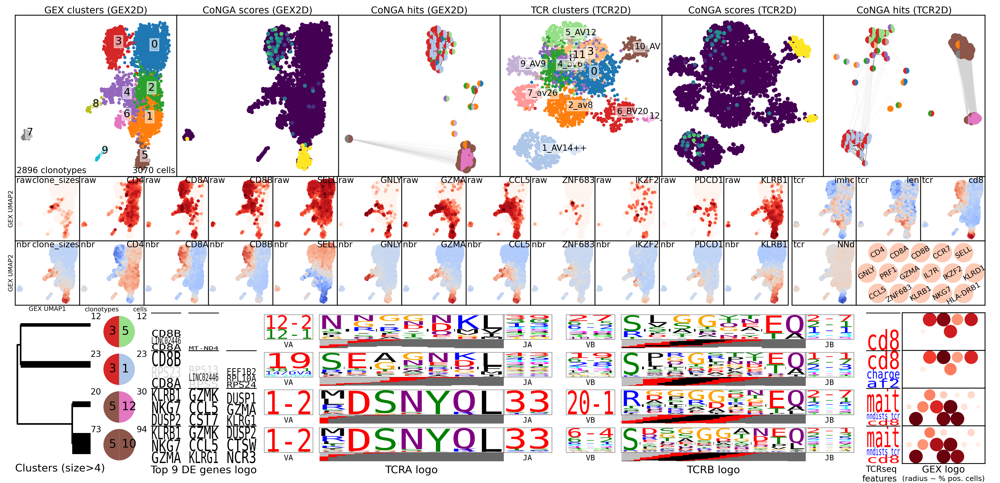

In [20]:
from PIL import Image               # for looking at some of 
from IPython.display import display # the output images.

tag = conga.tags.GRAPH_VS_GRAPH_LOGOS
pngfile = adata.uns['conga_results'].get(tag,None)
if pngfile is None:
    print('no graph-vs-graph clusters of sufficient size found')
else:
    help_message = adata.uns['conga_results'][tag+'_help']

    print(help_message)
    image = Image.open(pngfile)
    display(image)


## Run graph-vs-feature analysis, comparing the TCR graph to GEX features (mostly gene expression) and the GEX graph to TCR features (CDR3 features and V/J gene segments)

### First run the analysis, stashing the results in `adata.uns['conga_results']` and saving tables as `.tsv` files (since we pass in `outfile_prefix`)

In [21]:
conga.correlations.run_graph_vs_features(
    adata, all_nbrs, outfile_prefix=outfile_prefix)



making tcr score table, #features= 181
making tcr score table, #features= 181
making tcr score table, #features= 181
saved tcr_graph_vs_gex_features results to tsvfile: tmp_hs_pbmc_tcr_graph_vs_gex_features.tsv
saved tcr_genes_vs_gex_features results to tsvfile: tmp_hs_pbmc_tcr_genes_vs_gex_features.tsv
saved gex_graph_vs_tcr_features results to tsvfile: tmp_hs_pbmc_gex_graph_vs_tcr_features.tsv


### After running the analysis we can make the graph-vs-features plots

making: tmp_hs_pbmc_tcr_graph_vs_gex_features_plot.png
making: tmp_hs_pbmc_tcr_graph_vs_gex_features_panels.png
fastcluster is not available. Consider installing for faster performance.
computing pairwise X_pca_tcr distances, (2896, 50)
computing linkage matrix from pairwise X_pca_tcr distances
filling the score array for 61 features
making clustermap; num_features= 61


/home/pbradley/anaconda2/envs/scanpy_2021a/lib/python3.6/site-packages/seaborn/matrix.py:649: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


making: tmp_hs_pbmc_tcr_graph_vs_gex_features_clustermap.png
making: tmp_hs_pbmc_tcr_genes_vs_tcr_features_plot.png
making: tmp_hs_pbmc_gex_graph_vs_tcr_features_plot.png
making: tmp_hs_pbmc_gex_graph_vs_tcr_features_panels.png


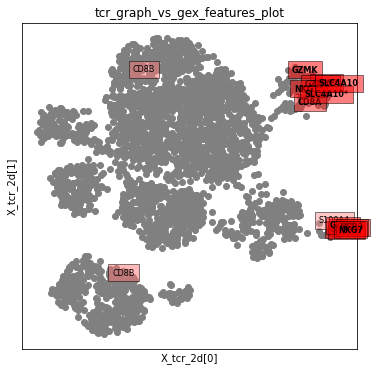

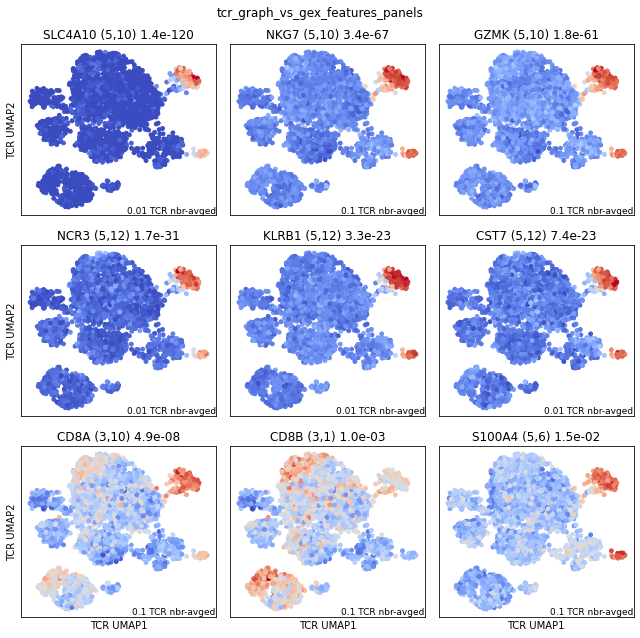

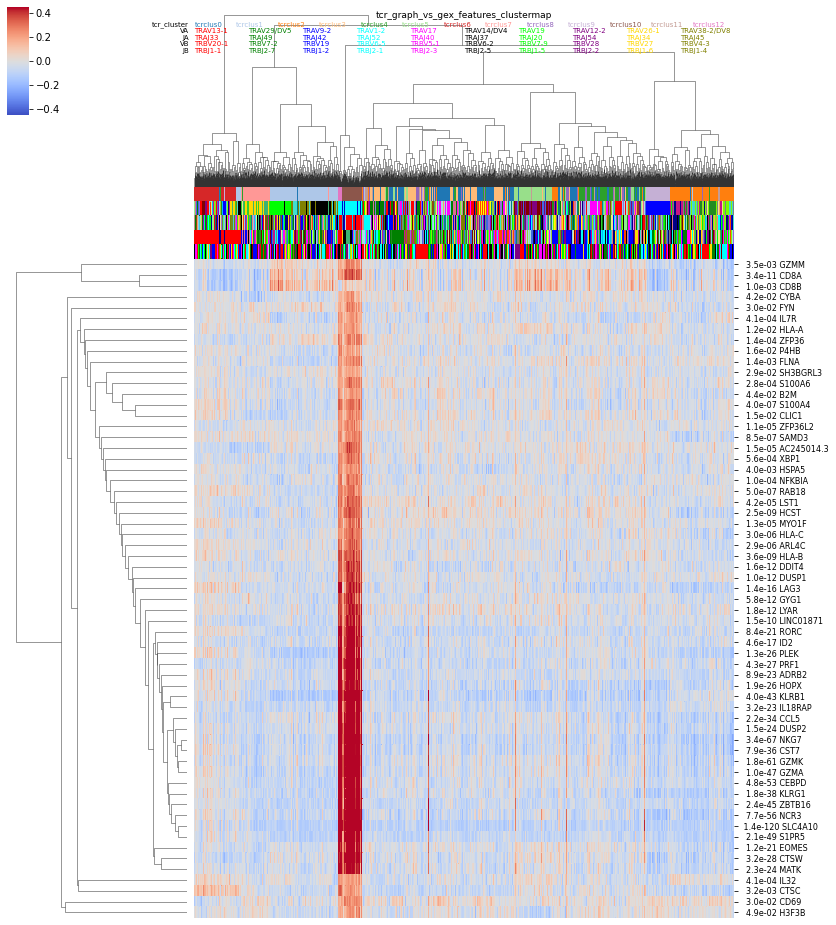

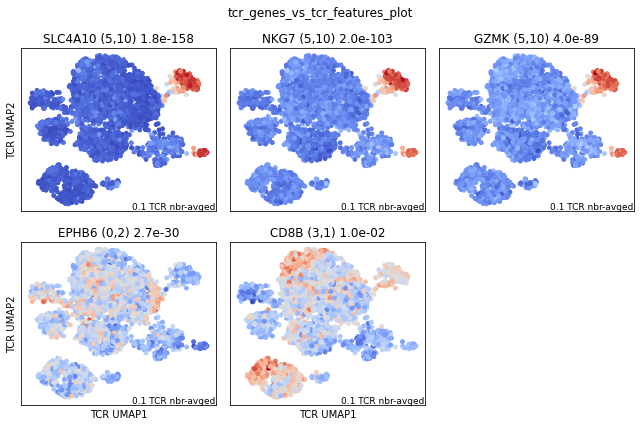

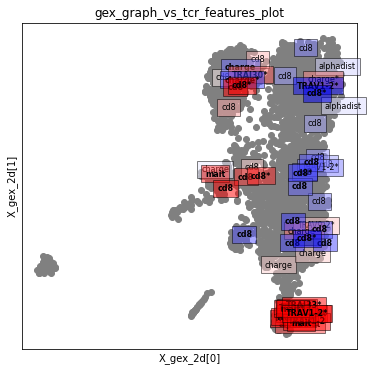

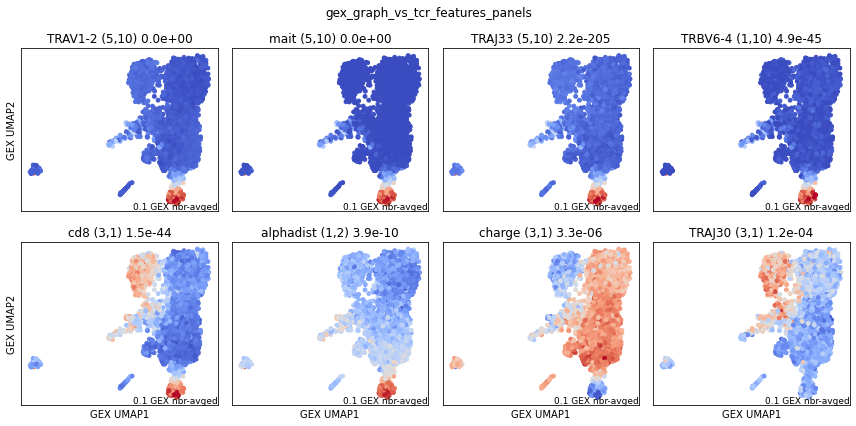

In [22]:
conga.plotting.make_graph_vs_features_plots(
    adata, all_nbrs, outfile_prefix)

## TCR matching to database

Here we match the TCRs in the dataset to a database of paired TCR sequences of 
known epitope specificity (or to a user-provided database using the `db_tcrs_tsvfile`
argument). The default database is `conga/data/new_paired_tcr_db_for_matching_nr.tsv` (see the readme file `conga/data/new_paired_tcr_db_for_matching_nr_README.txt` for information about where these TCR sequences come from. Major contributors are the VDJdb database, the McPAS database, the 10x 200k dataset, the Dash et al TCRdist dataset.)

In [23]:
match_results = conga.tcr_clumping.match_adata_tcrs_to_db_tcrs(
    adata, num_random_samples_for_bg_freqs=50000)

match_results.head()

tcr_clumping.match_adata_tcrs_to_db_tcrs: Matching to default literature TCR database; for more info see conga/data/new_paired_tcr_db_for_matching_nr_README.txt
Matching to paired tcrs in /home/pbradley/gitrepos/conga/conga/data/new_paired_tcr_db_for_matching_nr.tsv
num_comparisons: 11977856 2896 4136
parse_tcr_junctions: 0 2896
parse_tcr_junctions: 1000 2896
parse_tcr_junctions: 2000 2896
success_rate: 85.27
success_rate: 94.20
util.run_command: cmd= /home/pbradley/gitrepos/conga/tcrdist_cpp/bin/calc_distributions -f tmp_nbrs7138_tcrs.tsv -m 200 -d /home/pbradley/gitrepos/conga/tcrdist_cpp/db/tcrdist_info_human.txt -a tmp_nbrs7138_bg_achains.tsv -b tmp_nbrs7138_bg_bchains.tsv -o tmp_nbrs7138_dists.tsv
find_significant_tcrdist_matches:: max_dist: 200 max_dist_for_matching: 130
util.run_command: cmd= /home/pbradley/gitrepos/conga/tcrdist_cpp/bin/find_paired_matches -i tmpfile9302temp_query_tcrs.tsv -j tmpfile9302temp_db_tcrs.tsv -t 130 -d /home/pbradley/gitrepos/conga/tcrdist_cpp/db/tcr

,tcrdist,pvalue_adj,fdr_value,clone_index,db_index,va,cdr3a,vb,cdr3b,ja,...,db_jb,db_mhc,db_va,db_vb,db_pmhc,db_donor,db_is_second_alpha_chain,db_db,db_mhc_trim,barcode
0,36,0.001198,0.001198,42,3949,TRAV1-2*01,CAVRDGDYKLSF,TRBV6-4*01,CASSGGDDTGELFF,TRAJ20*01,...,,MR1,TRAV1-2*01,TRBV6-4*01,,NaN,,pdb,MR1,CCACGGACACCGAAAG-1
4,33,0.004791,0.002396,2354,1992,TRAV5*01,CAEDDNARLMF,TRBV20-1*01,CSARDREYGNTIYF,TRAJ31*01,...,TRBJ1-3*01,A*02:01,TRAV5*01,TRBV20-1*01,,NaN,,vdjdb,A*02,TGAAAGAAGACAGAGA-1
10,36,0.014373,0.004791,2354,2000,TRAV5*01,CAEDDNARLMF,TRBV20-1*01,CSARDREYGNTIYF,TRAJ31*01,...,TRBJ1-3*01,A*02:01,TRAV5*01,TRBV20-1*01,,NaN,,vdjdb,A*02,TGAAAGAAGACAGAGA-1
3,48,0.043120,0.010780,188,1924,TRAV12-1*01,CVVNGEDSSYKLIF,TRBV2*01,CASAPGQVAPDTQYF,TRAJ12*01,...,TRBJ2-3*01,A*02:01,TRAV12-1*01,TRBV2*01,,NaN,,vdjdb,A*02,CACACAACACCAGCAC-1
2,78,0.062285,0.012457,159,3649,TRAV10*01,CVVSDRGSTLGRLYF,TRBV25-1*01,CASGQGRQETQYF,TRAJ18*01,...,,,TRAV10*01,TRBV25-1*01,,NaN,,mcpas,,AGTGTCAAGGCAGGTT-1


## TCR clumping

This analysis identifies TCR neighborhoods that are overpopulated relative to a background
expectation based on a simple model of V(D)J recombination. These TCR clumps or clusters may
represent epitope-specific responses, invariant T cell populations, or other potentially
interesting T cell subsets. This analysis does not directly use the GEX information,
although we can subsequently look at GEX features of the identified clusters (see the tcr clumping logo plots below)



In [24]:
results = conga.tcr_clumping.assess_tcr_clumping(
    adata,
    outfile_prefix= outfile_prefix, # will save results as .tsv file
)

results.head()

parse_tcr_junctions: 0 2896
parse_tcr_junctions: 1000 2896
parse_tcr_junctions: 2000 2896
success_rate: 85.14
success_rate: 94.19
util.run_command: cmd= /home/pbradley/gitrepos/conga/tcrdist_cpp/bin/calc_distributions -f tmp_0.8443505168676155_tcr_clumping_tcrs.tsv -m 96 -d /home/pbradley/gitrepos/conga/tcrdist_cpp/db/tcrdist_info_human.txt -a tmp_0.8443505168676155_tcr_clumping_bg_achains.tsv -b tmp_0.8443505168676155_tcr_clumping_bg_bchains.tsv -o tmp_0.8443505168676155_tcr_clumping_dists.tsv
util.run_command: cmd= /home/pbradley/gitrepos/conga/tcrdist_cpp/bin/find_neighbors -f tmp_0.8443505168676155_tcr_clumping_tcrs.tsv -t 96 -d /home/pbradley/gitrepos/conga/tcrdist_cpp/db/tcrdist_info_human.txt -o tmp_0.8443505168676155_tcr_clumping -a tmp_0.8443505168676155_tcr_clumping_agroups.txt -b tmp_0.8443505168676155_tcr_clumping_bgroups.txt
saved tcr_clumping results to tsvfile: tmp_hs_pbmc_tcr_clumping.tsv


,clump_type,clone_index,nbr_radius,pvalue_adj,num_nbrs,expected_num_nbrs,raw_count,va,ja,cdr3a,vb,jb,cdr3b,clonotype_fdr_value,clumping_group,clusters_gex,clusters_tcr
28,global,85,96,1.857727e-33,18,0.068476,59153.0,TRAV1-2*01,TRAJ33*01,CAVKDSNYQLIW,TRBV6-4*01,TRBJ2-1*01,CASSDTGGEYNEQFF,1.857727e-33,1,5,10
70,global,118,96,1.804551e-32,17,0.056361,48857.0,TRAV1-2*01,TRAJ33*01,CAVMDSNYQLIW,TRBV6-4*01,TRBJ2-3*01,CASSDLAGPTDTQYF,9.022753e-33,1,5,10
46,global,99,96,1.687691e-30,17,0.073678,63647.0,TRAV1-2*01,TRAJ33*01,CAVLDSNYQLIW,TRBV6-4*01,TRBJ2-3*01,CASSPAGGADTQYF,5.625636e-31,1,5,10
85,global,132,96,1.358938e-29,16,0.059689,51706.0,TRAV1-2*01,TRAJ33*01,CAVRDSNYQLIW,TRBV6-4*01,TRBJ2-3*01,CASSSSGGATDTQYF,3.397345e-30,1,5,10
2,global,25,96,9.861772e-29,15,0.046886,40489.0,TRAV1-2*01,TRAJ12*01,CAGMDSSYKLIF,TRBV6-4*01,TRBJ2-3*01,CASSDTSGGADTQYF,1.972354e-29,1,5,10


### Make the tcr clumping plots

We can pass the same logo-configuring arguments to this function as to
`make_graph_vs_graph_logos` (see the graph-vs-graph description up above).

making tcr score table, #features= 35


... storing 'test' as categorical


run rank_genes_groups [('none', 2823), ('clp_0_1', 51), ('clp_0_2', 18), ('clp_0_3', 4)]
making cluster logos: 0 3 tmp_hs_pbmc_tcr_clumping_logos.png
making cluster logos: 1 3 tmp_hs_pbmc_tcr_clumping_logos.png
making cluster logos: 2 3 tmp_hs_pbmc_tcr_clumping_logos.png
making: tmp_hs_pbmc_tcr_clumping_logos.png
writing help message to file: tmp_hs_pbmc_tcr_clumping_logos.png_README.txt
making: tmp_hs_pbmc_tcr_clumping.png


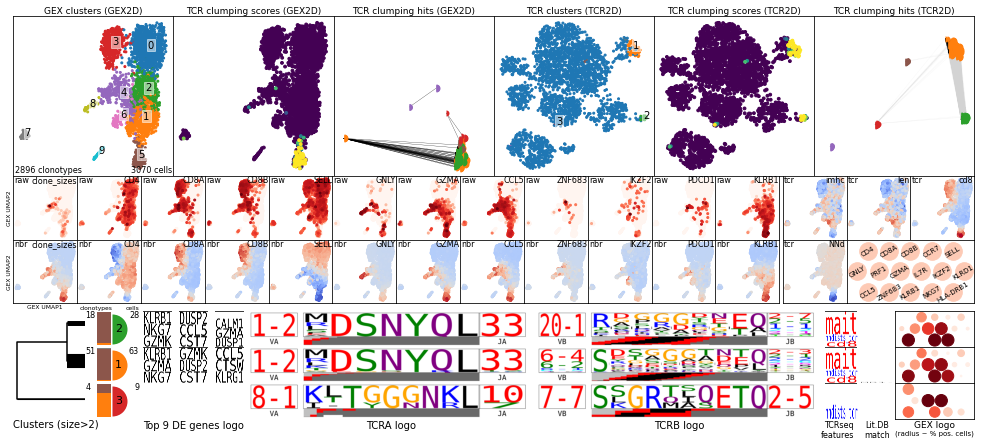

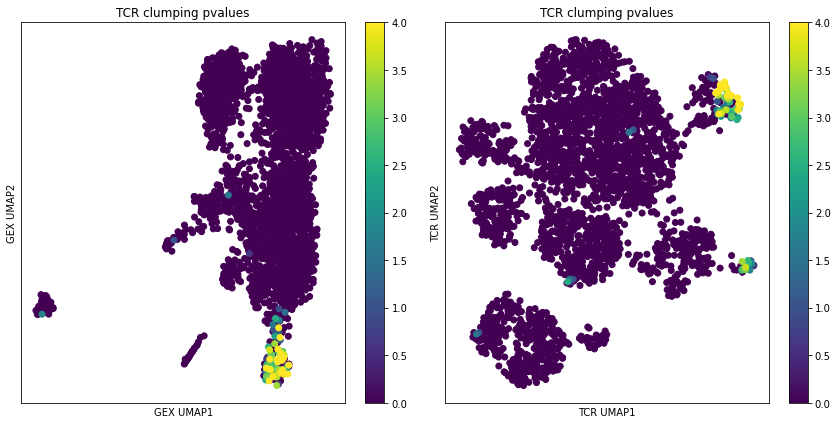

In [25]:
nbrs_gex, nbrs_tcr = all_nbrs[ max(nbr_fracs) ]

# now call plotting function, after results are stashed in adata
conga.plotting.make_tcr_clumping_plots(
    adata,
    nbrs_gex,
    nbrs_tcr,
    outfile_prefix,
    )


## Graph-vs-features analysis using the Yosef lab's `HotSpot` algorithm

DeTomaso, D., & Yosef, N. (2021). Hotspot identifies informative gene modules across modalities of single-cell genomics. Cell Systems, 12(5), 446–456.e9.

Here we use the HotSpot algorithm to identify TCR features that correlate with the GEX neighbor graph, or GEX features (expression of individual genes) that correlate with the TCR neighbor graph. The basic idea is that if two clonotypes are neighbors in the graph, then their feature values are correlated. This can be more sensitive than our original graph-vs-features analysis, which looks at the feature score distribution in each clonotype's
neighborhood individually, rather than across the entire graph (using the HotSpot 
H-statistic). On the other hand, features that are elevated in a very smal subpopulation 
may get a more significant score in the original CoNGA graph-vs-features analysis. So it's
worth looking at both analyses. 

This is a 'beta' version that does not incorporate all the cleverness in the HotSpot
algorithm. We find that neighbor graphs with small neighborhoods (e.g., nbr_fracs < 0.02)
sometimes give less interpretable/robust results. So here we are using only the 0.1
nbr_frac (ie, the K nearest neighbor graph with K = 0.1 * num_clonotypes).



In [26]:
results = conga.correlations.find_hotspots_wrapper(
    adata, all_nbrs, nbr_fracs = [0.1], outfile_prefix=outfile_prefix)

results.head(10)

conga.correlations.find_hotspots:: Using pval_threshold = 0.05
computing H matrix      0   2896     0.000000
computing H matrix   1000   2896    17.024279
computing H matrix   2000   2896    15.956836
computing H matrix      0   2896     0.000000
computing H matrix   1000   2896     5.431652
computing H matrix   2000   2896     5.125060
saved hotspot_features results to tsvfile: tmp_hs_pbmc_hotspot_features.tsv


,Z,pvalue_adj,feature,feature_type,nbr_frac
0,158.834951,0.0,gex_cluster5,gex,0.1
143,97.508607,0.0,tcr_cluster10,tcr,0.1
144,90.078225,0.0,cd8,tcr,0.1
145,85.045527,0.0,TRAJ33,tcr,0.1
146,83.514341,0.0,nndists_tcr,tcr,0.1
147,56.571804,0.0,TRBV6-4,tcr,0.1
142,136.767409,0.0,TRAV1-2,tcr,0.1
141,185.795005,0.0,mait,tcr,0.1
6,40.596392,0.0,S1PR5,gex,0.1
2,61.763277,0.0,NKG7,gex,0.1


making: tmp_hs_pbmc_hotspot_gex_features_0.100_nbrs_tcr_plot_umap_nbr_avg.png
making: tmp_hs_pbmc_hotspot_gex_features_0.100_nbrs_tcr_plot_umap_nbr_avg.png
fastcluster is not available. Consider installing for faster performance.
computing pairwise X_pca_tcr distances, (2896, 50)
computing linkage matrix from pairwise X_pca_tcr distances
filling the score array for 141 features
making clustermap; num_features= 109


/home/pbradley/anaconda2/envs/scanpy_2021a/lib/python3.6/site-packages/seaborn/matrix.py:649: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


making: tmp_hs_pbmc_hotspot_gex_features_0.100_nbrs_tcr_plot_clustermap_nbr_avg.png
making: tmp_hs_pbmc_hotspot_tcr_features_0.100_nbrs_gex_plot_umap_nbr_avg.png
making: tmp_hs_pbmc_hotspot_tcr_features_0.100_nbrs_gex_plot_umap_nbr_avg.png
fastcluster is not available. Consider installing for faster performance.
computing pairwise X_pca_gex distances, (2896, 40)
computing linkage matrix from pairwise X_pca_gex distances
filling the score array for 28 features
making clustermap; num_features= 25
making: tmp_hs_pbmc_hotspot_tcr_features_0.100_nbrs_gex_plot_clustermap_nbr_avg.png
making: tmp_hs_pbmc_hotspot_combo_features_0.100_nbrs_gex_plot_umap_nbr_avg.png
making: tmp_hs_pbmc_hotspot_combo_features_0.100_nbrs_gex_plot_umap_nbr_avg.png
fastcluster is not available. Consider installing for faster performance.
computing pairwise X_pca_gex distances, (2896, 40)
computing linkage matrix from pairwise X_pca_gex distances
filling the score array for 169 features
making clustermap; num_features

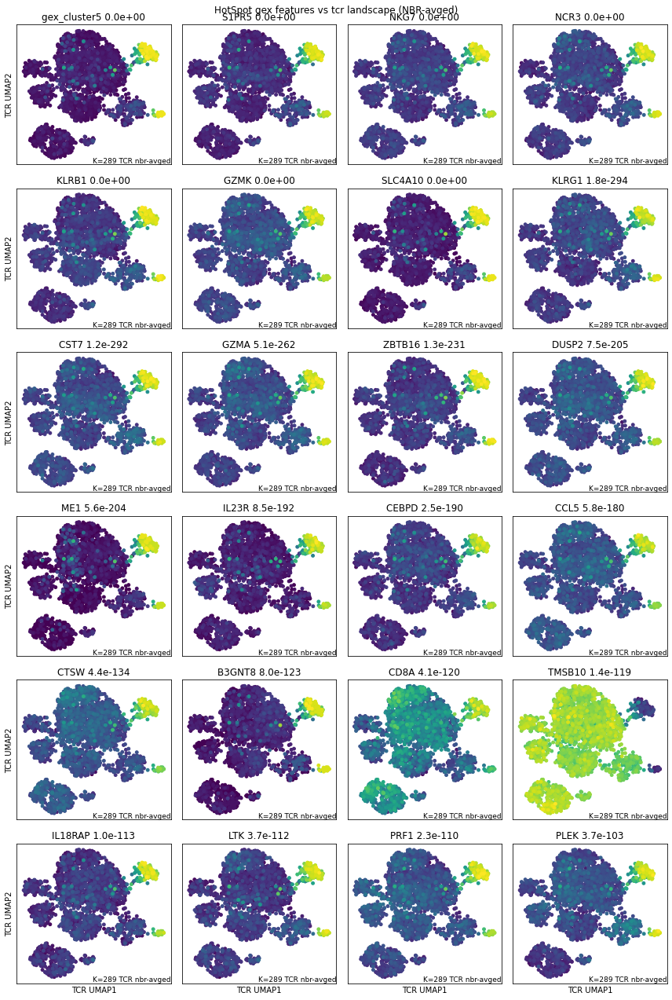

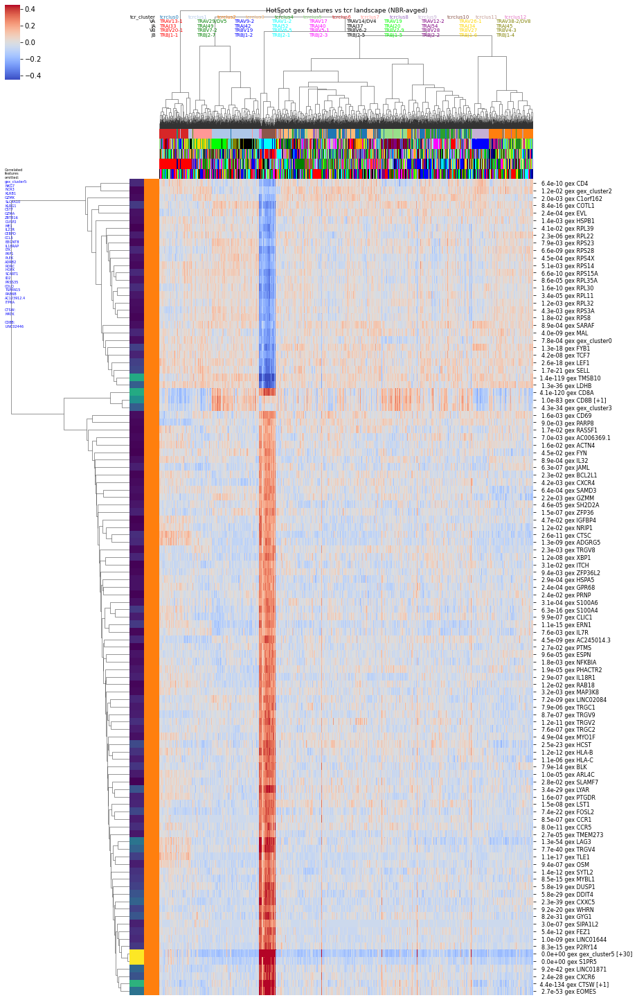

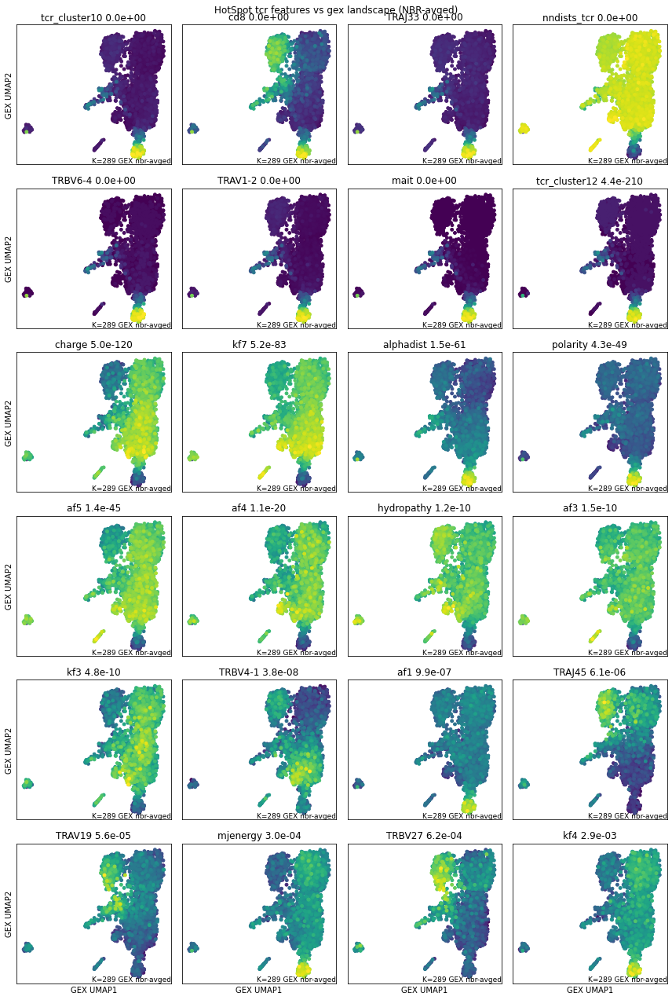

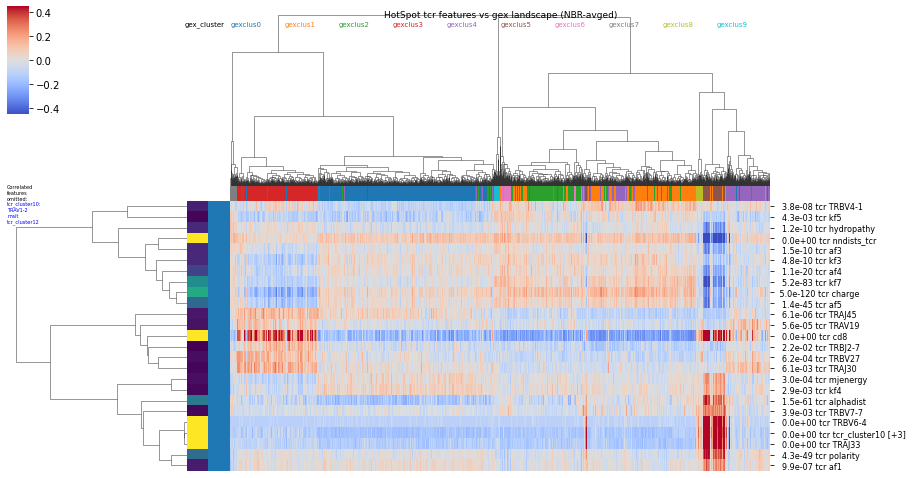

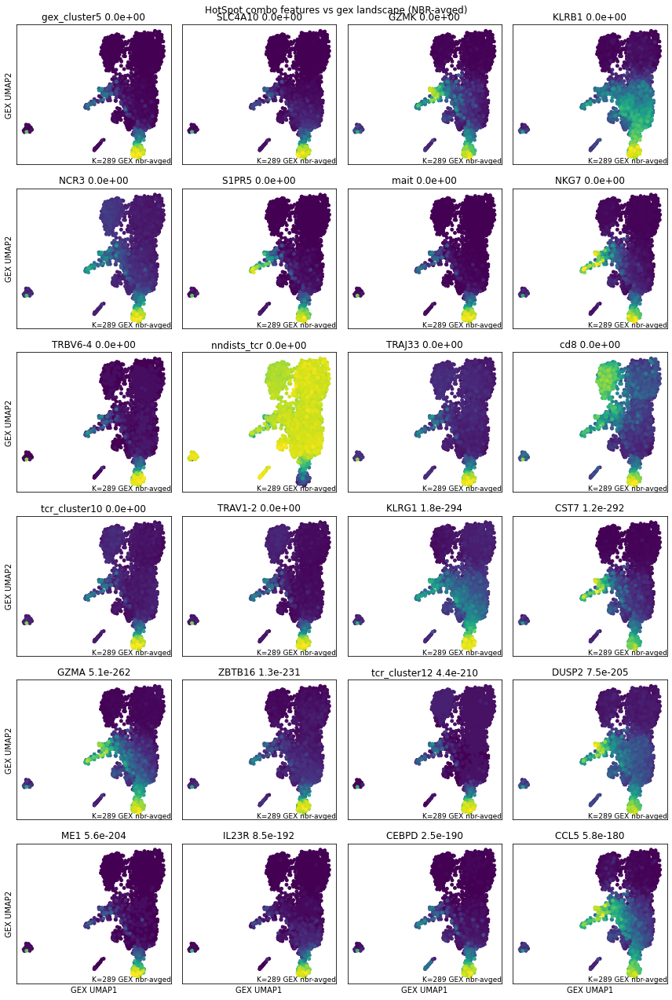

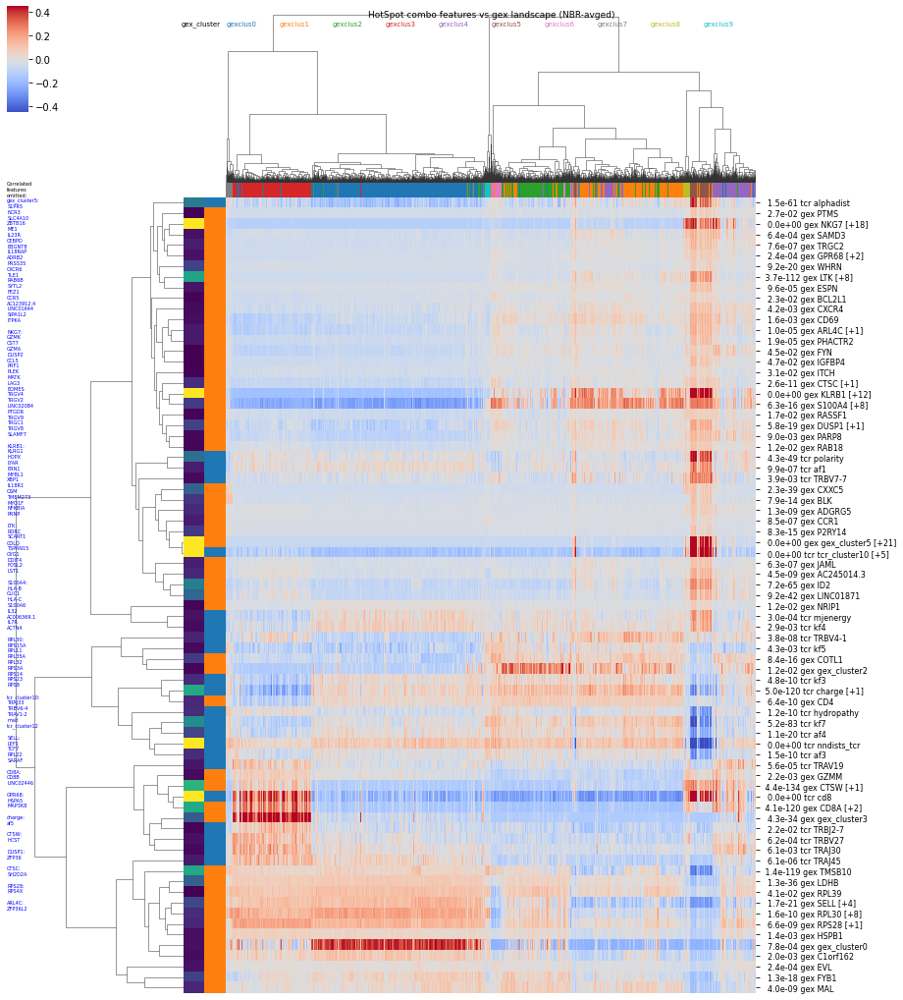

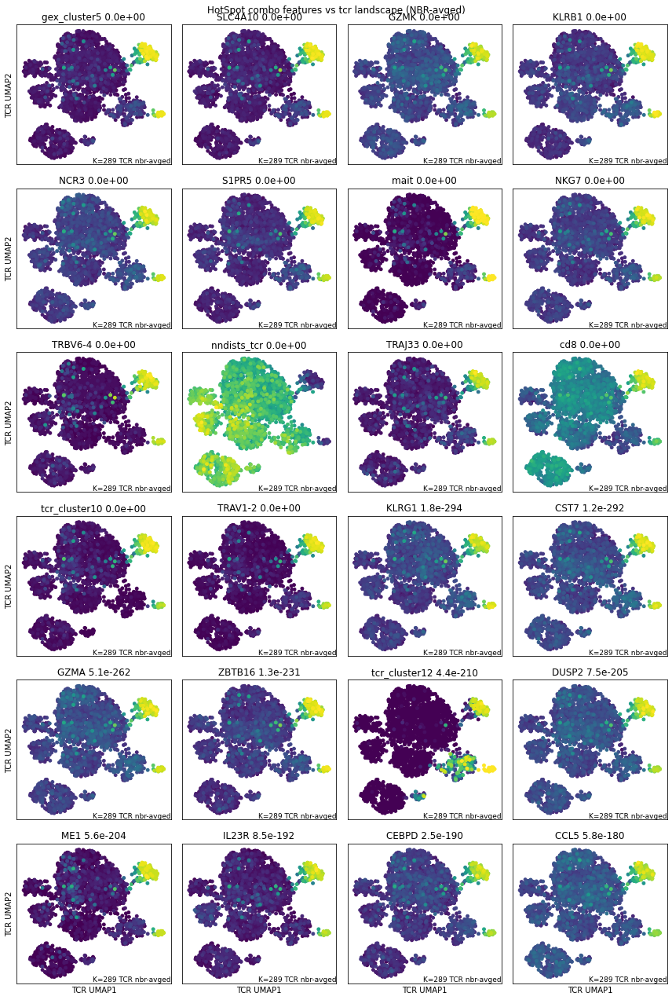

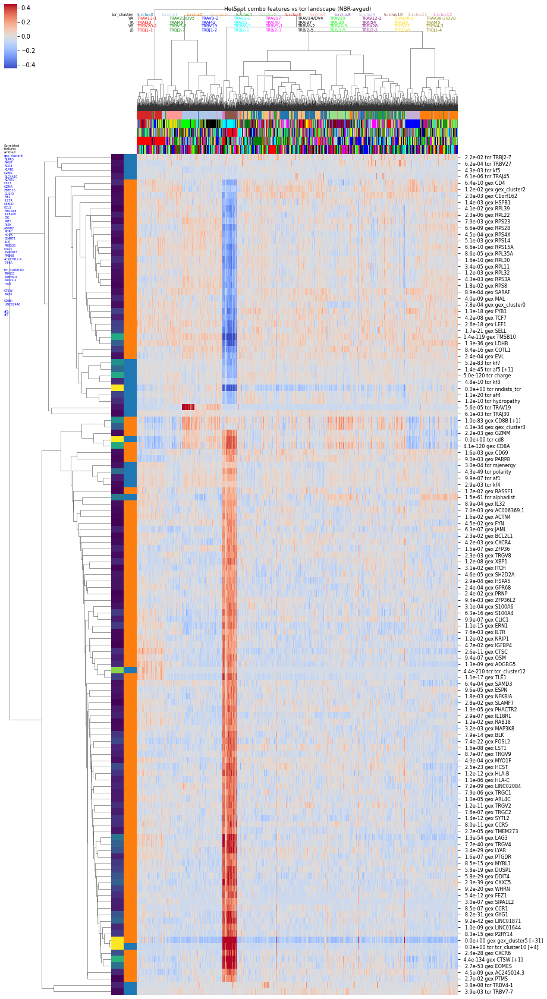

In [27]:
conga.plotting.make_hotspot_plots(
    adata, all_nbrs, outfile_prefix,
    )

## CoNGA can generate a summary `.html` file using the results in `adata.uns['conga_results']`

In [28]:

html_file = outfile_prefix+'_results_summary.html'
conga.plotting.make_html_summary(adata, html_file)

making: tmp_hs_pbmc_results_summary.html
make_html_summary:: no results for content_tag graph_vs_graph_stats
make_html_summary:: no results for content_tag graph_vs_summary
make_html_summary:: no results for content_tag gex_clusters_tcrdist_trees
make_html_summary:: no results for content_tag conga_threshold_tcrdist_tree


### display the summary html output here in the notebook

In [29]:
from IPython.display import display, HTML

html_lines = open(html_file,'r').read()

display(HTML(html_lines))

conga_score,num_neighbors_gex,num_neighbors_tcr,overlap,overlap_corrected,mait_fraction,clone_index,nbr_frac,graph_overlap_type,cluster_size,gex_cluster,tcr_cluster,va,ja,cdr3a,vb,jb,cdr3b
1.066112e-48,NaN,289.0,94,64,0.914894,107,0.1,gex_cluster_vs_tcr_nbr,115.0,5,10,TRAV1-2*01,TRAJ33*01,CAVMDSNYQLIW,TRBV6-4*01,TRBJ2-5*01,CASSEKTGGQETQYF
3.961754e-48,NaN,289.0,98,64,0.908163,89,0.1,gex_cluster_vs_tcr_nbr,121.0,5,10,TRAV1-2*01,TRAJ33*01,CAVKESNYQLIW,TRBV6-2*01,TRBJ2-5*01,CASSYTEQGSETQYF
1.287582e-47,NaN,289.0,90,64,0.911111,108,0.1,gex_cluster_vs_tcr_nbr,112.0,5,10,TRAV1-2*01,TRAJ33*01,CAVMDSNYQLIW,TRBV15*01,TRBJ2-3*01,CATSSPPGQGADTQYF
3.239912e-47,NaN,289.0,98,63,0.918367,63,0.1,gex_cluster_vs_tcr_nbr,121.0,5,10,TRAV1-2*01,TRAJ33*01,CAAMDSNYQLIW,TRBV6-2*01,TRBJ2-7*01,CASSLKGGGSDEQYF
4.358529e-47,NaN,289.0,97,63,0.927835,95,0.1,gex_cluster_vs_tcr_nbr,120.0,5,10,TRAV1-2*01,TRAJ33*01,CAVLDSNYQLIW,TRBV6-5*01,TRBJ2-5*01,CASSTSSGGAETQYF
4.468303e-46,NaN,289.0,89,63,0.910112,132,0.1,gex_cluster_vs_tcr_nbr,112.0,5,10,TRAV1-2*01,TRAJ33*01,CAVRDSNYQLIW,TRBV6-4*01,TRBJ2-3*01,CASSSSGGATDTQYF
4.664251e-46,NaN,289.0,89,63,0.921348,119,0.1,gex_cluster_vs_tcr_nbr,112.0,5,10,TRAV1-2*01,TRAJ33*01,CAVMDSNYQLIW,TRBV6-5*01,TRBJ2-1*01,CASSHGGGGHFNDEQFF
1.161718e-45,NaN,289.0,97,62,0.927835,60,0.1,gex_cluster_vs_tcr_nbr,121.0,5,10,TRAV1-2*01,TRAJ33*01,CAAKDSNYQLIW,TRBV6-2*01,TRBJ1-5*01,CASSYGDGSQPQHF
1.161718e-45,NaN,289.0,97,62,0.927835,143,0.1,gex_cluster_vs_tcr_nbr,121.0,5,10,TRAV1-2*01,TRAJ33*01,CAVTDSNYQLIW,TRBV6-4*01,TRBJ2-3*01,CASSDTSNAGTDTQYF
1.161718e-45,NaN,289.0,97,62,0.927835,43,0.1,gex_cluster_vs_tcr_nbr,121.0,5,10,TRAV1-2*01,TRAJ20*01,CAVRDQDYKLSF,TRBV6-4*01,TRBJ1-2*01,CASSDSEEGGLYGYTF
